In [49]:
import pandas as pd
import geopandas as gpd
import os
from pystac_client import Client
import boto3
from dotenv import load_dotenv
import xml.etree.ElementTree as ET
import time
import odc.stac
import numpy as np
import matplotlib.pyplot as plt
load_dotenv()

True

In [2]:
# credenciales
os.environ["AWS_ACCESS_KEY_ID"] = os.environ["CDSE_S3_ACCESS_KEY"]
os.environ["AWS_SECRET_ACCESS_KEY"] = os.environ["CDSE_S3_SECRET_KEY"]
os.environ["AWS_S3_ENDPOINT"] = "eodata.dataspace.copernicus.eu"
os.environ["AWS_VIRTUAL_HOSTING"] = "FALSE"
os.environ.pop("AWS_REGION", None)
os.environ.pop("AWS_NO_SIGN_REQUEST", None)

In [3]:
BAND_RESOLUTION = { "B01": 60, "B02": 10, "B03": 10, "B04": 10, "B05": 20, "B06": 20, "B07": 20, "B08": 10, "B8A": 20, "B09": 60, "B10": 60, "B11": 20, "B12": 20}
def bands_downsample(bands: list[str]):
    res = -float("inf")
    for b in bands:
        res = max(res, BAND_RESOLUTION[b])
    return res
    
def bands_upsample(bands: list[str]):
    res = -float("inf")
    for b in bands:
        res = min(res, BAND_RESOLUTION[b])
    return res

In [4]:
BUCKET_NAME = "eodata"
s3 = boto3.client(
    "s3",
    endpoint_url="https://eodata.dataspace.copernicus.eu",
    aws_access_key_id=os.environ["CDSE_S3_ACCESS_KEY"],
    aws_secret_access_key=os.environ["CDSE_S3_SECRET_KEY"],
)

In [5]:
FILE = "../../data/registros_limpios.geojson"
df = gpd.read_file(FILE)
df = df.to_crs(4326)

In [6]:
df.head(2)

,fecha,fuente,chla,grupo_nombre,estado_trofico,geometry
0,2017-01-02,OAN,8.9,RDP-MONTES,M,POINT (-58.07281 -34.20508)
1,2017-01-02,GEMS,6.8,LDS,O,POINT (-55.05017 -34.79501)


In [7]:
catalogo = Client.open("https://stac.dataspace.copernicus.eu/v1")
catalogo

<Client id=cdse-stac>

In [83]:
#laguna 3-5 dias
# m+ -10o#

# MAX_ACCEPTABLE
punto = df.iloc[1]

In [9]:
punto_fecha = punto["fecha"]
coords = punto.geometry
x_utm, y_utm = coords.x, coords.y
ventana = 5

#[(0, 0), (-1, 1), .... (-5, 5))]
# (-5, 5)
#for ventana in range(0, 6):

inicio = (punto["fecha"]- pd.Timedelta(days=ventana)).strftime("%Y-%m-%d")
fin = (punto["fecha"]+ pd.Timedelta(days=ventana)).strftime("%Y-%m-%d")
d = 0.005  # ~550m alrededor del punto
bbox = [x_utm - d, y_utm - d, x_utm + d, y_utm + d]

items = catalogo.search(
    collections=["sentinel-2-l1c"],
    datetime=f"{inicio}/{fin}",
    bbox=bbox,
).item_collection()


In [10]:
items[0]

<Item id=S2A_MSIL1C_20161229T133222_N0500_R081_T21HXB_20230923T131421>

In [11]:
candidatos_v2 = pd.DataFrame([
    {
        "id": it.id,
        "fecha_sensor": pd.Timestamp(it.datetime).tz_localize(None),
        "nubosidad_escena": it.properties.get("eo:cloud_cover"),
    }
    for it in items
])

candidatos_v2["diff_dias"] = (candidatos_v2["fecha_sensor"] - punto_fecha).abs().dt.days
candidatos_v2 = candidatos_v2.sort_values("diff_dias").reset_index(drop=True)
display(candidatos_v2)

item = [it for it in items if it.id == candidatos_v2.iloc[0]["id"]][0]
print("Elegido:", item.id)

,id,fecha_sensor,nubosidad_escena,diff_dias
0,S2A_MSIL1C_20161229T133222_N0500_R081_T21HXB_2...,2016-12-29 13:32:22.026,6.716,3


Elegido: S2A_MSIL1C_20161229T133222_N0500_R081_T21HXB_20230923T131421


In [13]:
pd.Timestamp(items[0].datetime)

Timestamp('2016-12-29 13:32:22.026000+0000', tz='tzutc()')

#### Download from bucket

In [14]:
def download_item_metadata(item):
    s3_key = item.assets["product_metadata"].href.replace("s3://eodata/", "")
    xml_bytes = s3.get_object(Bucket=BUCKET_NAME, Key=s3_key)["Body"].read()

    # Descargamos la metadata (en formato en XML)
    parsed_xml = ET.fromstring(xml_bytes)
    quant = float(parsed_xml.find(".//QUANTIFICATION_VALUE").text)
    offset = float(parsed_xml.find(".//RADIO_ADD_OFFSET").text)
    #print(f"Se descargaron {len(xml_bytes)} byteS")
    #print(f"{quant=}")
    #print(f"{offset=}")
    return quant, offset

In [36]:
QUANTIFICATION, RADIO_ADD_OFFSET = download_item_metadata(item)

In [16]:
t0 = time.time()
 
bands=["B04", "B05"]

ds = odc.stac.load(
    [item],
    bands=bands,
    crs="EPSG:32721",
    resolution=bands_downsample(bands),
    bbox=bbox,
    chunks=None,
    resampling="average"
)

print(f"Cargado en {time.time() - t0:.0f}s")
print(ds)

Cargado en 36s
<xarray.Dataset> Size: 12kB
Dimensions:      (y: 58, x: 48, time: 1)
Coordinates:
  * y            (y) float64 464B 6.149e+06 6.149e+06 ... 6.147e+06 6.147e+06
  * x            (x) float64 384B 6.779e+05 6.779e+05 ... 6.788e+05 6.788e+05
  * time         (time) datetime64[us] 8B 2016-12-29T13:32:22.026000
    spatial_ref  int32 4B 32721
Data variables:
    B04          (time, y, x) uint16 6kB 1732 1715 1723 1710 ... 1707 1708 1709
    B05          (time, y, x) uint16 6kB 1657 1653 1653 1652 ... 1637 1646 1643


In [24]:

ds

<xarray.Dataset> Size: 12kB
Dimensions:      (y: 58, x: 48, time: 1)
Coordinates:
  * y            (y) float64 464B 6.149e+06 6.149e+06 ... 6.147e+06 6.147e+06
  * x            (x) float64 384B 6.779e+05 6.779e+05 ... 6.788e+05 6.788e+05
  * time         (time) datetime64[us] 8B 2016-12-29T13:32:22.026000
    spatial_ref  int32 4B 32721
Data variables:
    B04          (time, y, x) uint16 6kB 1732 1715 1723 1710 ... 1707 1708 1709
    B05          (time, y, x) uint16 6kB 1657 1653 1653 1652 ... 1637 1646 1643

In [25]:
ds.dims

FrozenMappingWarningOnValuesAccess({'y': 58, 'x': 48, 'time': 1})

In [ ]:
[2, N, M, 1]

In [32]:
ds.isel(time=0)

<xarray.Dataset> Size: 12kB
Dimensions:      (y: 58, x: 48)
Coordinates:
  * y            (y) float64 464B 6.149e+06 6.149e+06 ... 6.147e+06 6.147e+06
  * x            (x) float64 384B 6.779e+05 6.779e+05 ... 6.788e+05 6.788e+05
    spatial_ref  int32 4B 32721
    time         datetime64[us] 8B 2016-12-29T13:32:22.026000
Data variables:
    B04          (y, x) uint16 6kB 1732 1715 1723 1710 ... 1708 1707 1708 1709
    B05          (y, x) uint16 6kB 1657 1653 1653 1652 ... 1648 1637 1646 1643

### reflectancia = (DN + RADIO_ADD_OFFSET) / QUANTIFICATION_VALUE

In [34]:
escena = ds.isel(time=0) # b04 = Red, 
B04 = escena["B04"]
B05 = escena["B05"]

In [37]:
B04_r = (B04 + RADIO_ADD_OFFSET) / QUANTIFICATION

In [39]:
B04_r

<xarray.DataArray 'B04' (y: 58, x: 48)> Size: 22kB
array([[0.0732, 0.0715, 0.0723, ..., 0.072 , 0.0717, 0.0699],
       [0.0721, 0.0724, 0.0711, ..., 0.0706, 0.0709, 0.0724],
       [0.0725, 0.0723, 0.0714, ..., 0.0715, 0.0699, 0.0708],
       ...,
       [0.0722, 0.0716, 0.0715, ..., 0.0719, 0.0703, 0.0711],
       [0.0717, 0.0705, 0.0714, ..., 0.0708, 0.0714, 0.0715],
       [0.0715, 0.0711, 0.072 , ..., 0.0707, 0.0708, 0.0709]],
      shape=(58, 48))
Coordinates:
  * y            (y) float64 464B 6.149e+06 6.149e+06 ... 6.147e+06 6.147e+06
  * x            (x) float64 384B 6.779e+05 6.779e+05 ... 6.788e+05 6.788e+05
    spatial_ref  int32 4B 32721
    time         datetime64[us] 8B 2016-12-29T13:32:22.026000
Attributes:
    nodata:   0

In [41]:
B05_r = (B05 + RADIO_ADD_OFFSET)/ QUANTIFICATION


In [42]:
B05_r 

<xarray.DataArray 'B05' (y: 58, x: 48)> Size: 22kB
array([[0.0657, 0.0653, 0.0653, ..., 0.0645, 0.0641, 0.0658],
       [0.0651, 0.0653, 0.0653, ..., 0.0647, 0.0643, 0.066 ],
       [0.065 , 0.0657, 0.0647, ..., 0.0647, 0.0647, 0.0653],
       ...,
       [0.0658, 0.0663, 0.066 , ..., 0.0648, 0.064 , 0.0642],
       [0.0653, 0.0658, 0.0652, ..., 0.0639, 0.0645, 0.064 ],
       [0.0652, 0.0658, 0.0653, ..., 0.0637, 0.0646, 0.0643]],
      shape=(58, 48))
Coordinates:
  * y            (y) float64 464B 6.149e+06 6.149e+06 ... 6.147e+06 6.147e+06
  * x            (x) float64 384B 6.779e+05 6.779e+05 ... 6.788e+05 6.788e+05
    spatial_ref  int32 4B 32721
    time         datetime64[us] 8B 2016-12-29T13:32:22.026000
Attributes:
    nodata:   0

In [55]:
escena_r = np.stack([
    B04_r,
    B05_r
], axis=-1)

In [56]:
escena_r.shape

(58, 48, 2)

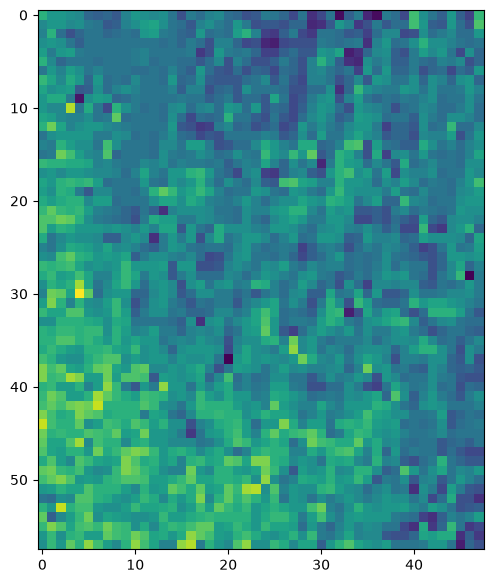

In [58]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(B05_r)

In [59]:
VENTANA_ESPACIAL = 3

In [84]:
punto = gpd.GeoSeries([punto.geometry], crs="EPSG:4326")
punto = punto.to_crs(epsg=32721) 

In [85]:
punto

0    POINT (678380.002 6147956.963)
dtype: geometry